<a href="https://colab.research.google.com/github/blueberrycrumble/AIFFEL_quest_cr/blob/master/notebooks/FashionMNIST_torch_Classifier_March2025.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# -*- coding: utf-8 -*-
"""
Created on Tue Mar 11 20:55:52 2025

@author credit: Janne Merilinna
@contributor(translation & commentary): Hyeseung Lee

이 노트는 파이썬, 머신러닝, 딥러닝과 친해지고자 하는 입문자(본인)를 대상으로 쓰여졌습니다.
PyTorch로 구현한 노트의 원문은 [여기서](https://github.com/jmerilinna/education/blob/master/learning/mnist_efficientnet_baseline.ipynb) 확인하실 수 있습니다.
입문자가 각 코드블록의 목적을 이해하기 쉽게 최대한 Docstring 과 주석, 참조를 남겼습니다.
Colab의 실행 환경에 대비해 훈련 모델을 저장하는 콜백 클래스를 기존 코드에 추가했습니다.
초기 실험은 Daycon 참가자에게 제공된 아이콘 이미지 분류를 목적으로 했으며,
이후 기록 저장과 모델의 범용성 테스트를 위해서 데이터셋을 FashionMNIST으로 바꾸어 재현했음을 밝힙니다.
"""

# %%

# 그레이스케일 이미지 분류기 모델로 PyTorch 시작하기

## 1. 소개

PyTorch는 이미지와 같은 비정형 데이터를 다룰 때 신경망을 구축하기 위한 훌륭한 프레임워크입니다. 기본 설정을 위해 약간의 boilerplate code<sub>1</sub>가 필요하지만 일단 설정이 완료되면, 실험에 집중할 수 있는 환경이 열립니다.  
  
모델을 처음부터 설계하는 대신, 가장 작은 EfficientNet 모델을 사용하겠습니다. 기존 아키텍처를 재사용하는 것은 현재 표준 작업에 있어 필수적입니다. 사전 훈련된 모델을 사용하지 않고 구조만 수정해서 그레이스케일 이미지(또는 RGB)를 처리하도록 첫 번째 Convolution 블록을 교체하고, decision head <sub>2</sub>를 클래스 수에 맞게 조정합니다.

나머지는 기본 훈련법을 따르되 검증을 위한 몇 가지 트릭을 추가했습니다.  
일반적으로는 훈련 중 검증 세트를 사용하여 모델이 보지 못한 데이터에서 어떻게 수행하는 지 확인하지만, 이 노트에 사용된 데이터처럼 작은 검증 세트에서는 운이 개입할 수 있습니다. 모델이 "우연히" 높은 성능을 보이는 경우를 방지하기 위한 한 가지 전략으로 이 노트에서는 이미지 증강을 훈련과 검증 모두에게 적용하겠습니다. 훈련 중에 검증 세트를 증강하는 것은 모델이 -더 모호할 수 있는 테스트 데이터가 주어졌을 때- 자신을 증명해야 하는 더 현실적인 성능 평가를 제공합니다. 모델이 이미지의 핵심적인 특징을 학습하지 않는다면, 계속해서 바뀌는 타겟에 대해 높은 false accuracy를 보여주기는 힘들 것이라고 가정합니다.   
  
이 아이디어를 추론 과정에도 적용하여 Test-Time Augmentation(TTA)<sub>3</sub> 기법을 사용합니다. 원본 이미지 하나를 예측하는 대신, 원본 이미지를 여러 버전으로 증강하고 각각의 버전을 모두 예측한 후, 모델이 최종 결과에 대해 투표하도록 합니다. 모델의 성능을 높여줄 수 있는 좋은 방법입니다.  
  
---
</dir> 참조 </br>
</dir> [1] boilerplate code: 여러 프로젝트나 프로젝트 내에서 반복적으로 사용되는 코드 조각.  일관된 코드 구조를 제공해 표준화와 효율성을 높일 수 있습니다.</br>
</dir> [2] decision head: 신경망에서 입력 데이터의 특징을 추출한 후, 최종적으로 클래스에 대한 예측을 수행하는 부분을 의미합니다.</br>&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;</dir>결정 헤드를 클래스 수에 맞게 조정하는 것은 모델이 특정 문제에 맞게 최적화되도록 하는 중요한 과정입니다.</br>      
</dir> [3] Test-Time Augmentation: [참조 링크](https://modulabs.co.kr/blog/test-time-augmentation-computer-vision)</br>  

## 2. 분류기에 필요한 필수 코드

그레이스케일 분류기를 위한 함수들을 우선 조립해보겠습니다. 각 함수에 대한 자세한 정보는 docstring<sub>4</sub>을 참조해주세요.

- `load_fashion_mnist`는 데이터셋을 가져옵니다.  
28x28 크기의 의류와 신발 이미지로 구성된 10개의 클래스로 나누어진 그레이스케일 이미지입니다.
- `apply_augmentation`는 이미지 증강에 사용됩니다.
- 이미지 증강은 `SaltAndPepperNoise`와 `GaussianNoise`를 사용하여 모델의 내구성을 테스트합니다. PyTorch의 내장 옵션에 약간의 커스터마이징을 더했습니다.
- `ImageDataset`은 PyTorch의 `DataLoader`를 통해 증강된 이미지를 전달합니다.
- `EfficientNetClassifier`는 훈련 및 추론을 위한 fit-predict 프레임워크를 제공합니다. fit 메서드는 데이터에 대한 검증, 조기 종료, 훈련이 중단 될 때 최상의 모델로 롤백하는 기능을 포함합니다.  
- `SaveModelEveryNEpochs` 는 지정 에포크마다 model_path가 가르키는 경로에 모델을 저장합니다.  
가중치도 함께 저장할 지 선택할 수 있습니다.
  
-----
</dir> 참조 </br>
</dir> [4] Docstring: 코드 내에서 함수, 클래스, 모듈 등의 기능과 목적을 설명하는 문자열입니다.</br>&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;</dir>주석처리된 단락에서 함수의 파라미터, 반환값, 예외처리에 대한 정보를 확인할 수 있습니다. </br>


In [ ]:
# 라이브러리 불러오기
import logging
import warnings
import os

import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import mode
from sklearn.model_selection import train_test_split
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.metrics import accuracy_score, f1_score
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from torchvision import models, transforms, datasets
from tqdm import tqdm

warnings.filterwarnings("ignore")
logging.basicConfig(level=logging.INFO, format="%(asctime)s - %(levelname)s - %(message)s")

plt.rcParams['figure.figsize'] = (12,6)
plt.rcParams['figure.constrained_layout.use'] = True

In [ ]:
# 이미지 분류를 위한 함수 정의 블록

def load_fashion_mnist():
    '''
    Fashion MNIST 파일을 다운로드 하는 함수
    images(X), NumPy arrays(Y) 반환
    '''
    train = datasets.FashionMNIST(root="./data", train=True, download=True)
    test = datasets.FashionMNIST(root="./data", train=False, download=True)

    X = np.concatenate([(train.data/255.0).reshape(len(train),-1),
                        (test.data/255.0).reshape(len(test),-1)])
    Y = np.concatenate([train.targets, test.targets])

    return X.astype(np.float32), Y.astype(np.int64), train.classes

def apply_augmentation(image, augmentation_transforms, num_samples=5):
    '''
    하나의 이미지 원본에 대한 여러장의 증강 이미지를 생성하는 클래스

    Args
    -----
    image : np.ndarrary or torch.Tensor
        인풋 이미지 (flattened or HwW)
    augmentation_transforms : callable
        적용할 증강 방식
    num_samples : int
        증강 수량 (기본: 5장)

    Raises
    ------
    ValueError
        이미지 크기 또는 샘플 수가 다를 경우

    Returns
    -------
    augmented_images : NumPy arrary
        리스트에 담겨서 반환되는 증강 이미지

    '''
    if num_samples <= 0:
        raise ValueError(f"num_samples must be positive, got {num_samples}")

    # NumPy를 tensor로 변환
    if isinstance(image, np.ndarray):
        if image.dtype == np.uint8:
            image = image.astype(np.float32) / 255.0
        elif image.dtype not in (np.float32, np.float64):
            raise ValueError(f"Unsupported dtype: {image.dtype}")
        else:
            image = image.astype(np.float32)

        # 이미지 형태(shape)에 대한 에러 핸들링: flattened or 2D square
        if image.ndim == 1:
            n = int(image.shape[0] ** 0.5)
            if n*n != image.shape[0]:
                raise ValueError(f"Flattened size {image.shape[0]} must be a perfect square")
            image = image.reshape(n, n)
        elif image.ndim == 2 and image.shape[0] != image.shape[1]:
            raise ValueError(f"Image must be square, got {image.shape}")
        elif image.ndim > 2:
            raise ValueError(f"Expected 1D or 2D input, got {image.shape}")

        image = torch.tensor(image, dtype=torch.float32).unsqueeze(0)

    # 텐서 크기 검증 (1, H, H)
    if image.dim() != 3 or image.shape[1] != image.shape[2]:
        raise ValueError(f"Tensor must be 1xHxH (square grayscale), got {image.shape}")

    # 증강 이미지 생성
    augmented_images = [
        augmentation_transforms(image.clone()).squeeze(0).cpu().numpy()
        for _ in range(num_samples)
        ]

    return augmented_images

class SaltAndPepperNoise:
    '''
    머신러닝에서 데이터 증강 기법으로 활용되는 salt & pepper noise를 추가하는 클래스
    입력된 확률에 따라 소금&후추 노이즈가 랜덤하게 텐서의 요소를 대체한다.
    0(pepper) or 1(salt)

    Parameters
    ----------
    prob: float, optional
        텐서의 각 요소가 노이즈(0 또는 1)로 대체될 확률
        0과 1 사이의 수만 입력 가능하다. (기본 0.05)

    Methods
    -------
    __call__(tensor)
        인풋 텐서에 소금&후추 노이즈 적용

        Parameters
        ----------
        tensor: torch.Tensor
            노이즈가 추가될 인풋 텐서

        Returns
        torch.Tensor
            소금&후추 노이즈가 적용된 텐서 반환
        -------
    '''
    def __init__(self, prob=0.05):
        self.prob = prob

    def __call__(self, tensor):
        mask = torch.rand(tensor.size()) < self.prob
        tensor[mask] = torch.randint(0, 2, mask.sum().size(), dtype=torch.float32).to(tensor.device)
        return tensor

class GaussianNoise:
    '''
    머신러닝에서 데이터 증강 기법으로 활용되는 Gaussian Noise를 적용하는 클래스

    지정된 평균과 표준 편차를 갖는 정규 분포에서 샘플링된 랜덤 값을
    텐서 요소에 추가한다.

    Parameters
    -----------
    mean: float, optional
        가우시안 노이즈의 평균값 (기본 0.0)
    std: float, optional
        가우시안 노이즈의 표준 편차. 0 이상의 값이어야 하며, 음수일 수 없습니다. (기본 0.1)

    Methods
    -------
    __call__(tensor)
        입력 텐서에 가우시안 노이즈 추가

        Parameters
        ----------
        tensor: torch.Tensor
            노이즈를 추가할 입력 텐서

        Returns
        -------
        torch.Tensor
            가우시안 노이즈가 추가된 텐서
    '''
    def __init__(self, mean=0.0, std=0.1):
        self.mean = mean
        self.std = std

    def __call__(self, tensor):
        noise = torch.randn(tensor.size()) * self.std + self.mean
        return tensor + noise

    def __repr__(self):
        return f"{self.__class__.__name__}(mean={self.mean}, std={self.std})"

class ImageDataset(Dataset):
    '''
    PyTorch의 내장클래스(http://tutorials.pytorch.kr/beginner/basics/data_tutorial.html)

    Parameters
    ----------
    X: array-like
        NumPy 배열 형태의 입력 이미지. 1D(flattened square images) 또는 2D(square iamges)일 수 있습니다.
        예상 데이터 타입: uint8 (0-255) 또는 float32/float64 (0-1).
    Y: array-like, optional
        이미지에 해당하는 라벨. X와 길이가 같아야 합니다.(기본 None: 라벨 없음)
    transform: callable, optional
        각 이미지 텐서에 적용할 변환 함수
        예시: torchvision.transforms의 변환 함수 또는 커스텀 함수
        PyTorch 텐서를 입력으로 받고, 변환된 텐서를 반환해야 합니다. (기본 None: 변환 없음)

    Attributes
    ----------
    X: np.darray
        입력 이미지 데이터(Numpy 배열)
    Y: np.darray 또는 None
        라벨 데이터(Numpy 배열) 또는 None(라벨이 없는 경우)
    transforms: callable or None
        이미지에 적용할 변환 함수

    Methods
    -------
    __len__()
        데이터셋의 샘플 수 반환
    __getitem__(idx)
        주어진 인덱스의 이미지(및 라벨이 있는 경우, 해당 라벨)를 가져와 처리 후 반환

    Raises
    ------
    ValueError
        X와 Y의 길이가 일치하지 않는 경우
        X의 데이터 타입이 지원되지 않는 경우
        평탄화된 이미지의 크기가 완전한 정사각형이 아닌 경우
        2D 입력이 정사각형이 아닌 경우
    TypeError
        transform이 제공되었으나 호출할 수 없는 경우.

    '''
    def __init__(self, X, Y=None, transform=None):
        self.X = np.asarray(X)
        self.Y = np.asarray(Y) if Y is not None else None
        self.transform = transform
        if Y is not None and len(X) != len(Y):
            raise ValueError(f"Length mismatch: X ({len(X)}), Y ({len(Y)})")
        if transform and not callable(transform):
            raise TypeError(f"transform must be callable, got {type(transform)}")

    def __len__(self):
        '''
        데이터셋의 총 샘플 수를 반환

        Returns
        -------
        int
            데이터셋에 있는 이미지 개수
        '''
        return len(self.X)

    def __getitem__(self, idx):
        '''
        주어진 인덱스의 이미지(및 라벨, 있을 경우)를 가져와서 처리하는 메서드

        이 메서드는 이미지 데이터를 정규화하고, 정사각형 모양으로 재구성한 후, PyTorch 텐서로 변환합니다.
        transform이 지정되었다면 적용 후에 최종 결과를 반환
        라벨이 있는 경우, 해당 라벨도 텐서로 변환하여 함께 반환

        Parameters
        ----------
        idx : int
            가져올 샘플의 인덱스

        Raises(예외처리)
        ------
        ValueError
            이미지의 데이터 타입이 지원되지 않는 경우
            평탄화된 이미지 크기가 완전한 정사각형이 아닌 경우
            2D입력이 정사각형이 아닌 경우
            입력 데이터가 2차원을 초과하는 경우

        Returns
        -------
        tuple 또는 torch.Tensor
            Y가 주어진 경우: (image_tensor, label_tensor)형태로 반환
            Y가 None인 경우: image_tensor만 반환
            image_tensor: (1, H, W) 형태의 torch.Tensor, dtype=float32
            label_tensor: torch.Tensor, dtype=long (Y가 있을 경우)
        '''
        x = self.X[idx]
        # 데이터 타입(dtype) 정규화
        if x.dtype == np.uint8:
            x = x.astype(np.float32) / 255.0
        elif x.dtype not in (np.float32, np.float64):
            raise ValueError(f"Unsupported dtype: {x.dtype}")
        else:
            x = x.astype(np.float32)

        # 데이터 형태(shape) 처리
        if x.ndim == 1:
            n = int(x.shape[0] ** 0.5)
            if n * n != x.shape[0]:
                raise ValueError(f"Flattened size {x.shape[0]} must be a perfect square")
            x = x.reshape(n, n)
        elif x.ndim == 2 and x.shape[0] != x.shape[1]:
            raise ValueError(f"2D input must be square, got {x.shape}")
        elif x.ndim > 2:
            raise ValueError(f"Expected 1D or 2D input, got shape {x.shape}")

        x = torch.tensor(x, dtype=torch.float32).unsqueeze(0)
        if self.transform:
            x = self.transform(x)

        return (x, torch.tensor(self.Y[idx], dtype=torch.long)) if self.Y is not None else x

class  EfficientNetClassifier():
    def __init__(self, num_classes, pretrained=False, device=None, augmentation=None, metrics=None, mean=0.5, std=0.5):
        '''
        흑백 이미지(싱글채널)를 처리하는 EfficientNet 기반 분류기 클래스
        EfficientNet 분류 모델 초기화

        Args(매개변수)
        ----
        num_classes : int
            출력 클래스 개수
        pretrained : bool, optional
            사전 학습된 가중치 사용 여부
            True: 사용, False: 랜덤 초기화 (기본 False)
        device : str, optional
            모델이 실행될 장치
            'cuda','cpu', None(기본값)
        augmentation : callable, optional
            훈련 시 사용할 데이터 증강 함수 (기본 None: 변환없음)
        metrics : list, optional
            모델 평가 시 사용할 지표, 리스트로 제공 가능
        mean : float, optional
            이미지 정규화 시 사용할 평균값 (기본 0.5)
        std : float, optional
            이미지 정규화 시 사용할 표준 편차 값 (기본 0.5)

        Raises(예외 처리)
        ------
        ValueError
            num_classes, device, mean, std, 또는 metrics 값이 유효하지 않을 경우 발생
        TypeError
            metrics 또는 augmentation이 바른 타입이 아닐 경우 발생
        '''
        # 핵심 매개변수 검증
        if not isinstance(num_classes, int) or num_classes <= 0:
            raise ValueError(f"num_classes must be positive, got {num_classes}")
        if device and device not in ['cpu', 'cuda']:
            raise ValueError(f"Invalid device: {device}. Use 'cuda', 'cpu', or None")
        if std <= 0:
            raise ValueError(f"std must be positive, got {std}")

        # 매개변수 저장
        self.mean = mean
        self.std = std
        self.num_classes = num_classes
        self.pretrained = pretrained
        self.device = device if device else ('cuda' if torch.cuda.is_availabel() else 'cpu')

        # 데이터 증강 및 검증
        self.augmentation = augmentation or None        # 증강함수를 None으로 정규화
        if augmentation and not callable(augmentation): # augmentation이 함수가 아니면 TypeError 발생
            raise TypeError(f"augmentation must be callable, got {type(augmentation)}")
        self.metrics = metrics if metrics is not None else []
        if not isinstance(self.metrics, (list, tuple)):
            raise TypeError(f"metrics must be a list/tuple, got {type(metrics)}")

        # 평가 지표 설정 및 검증
        supported_metrics = {
            'accuracy': accuracy_score,
            'f1_score': lambda y_true, y_pred: f1_score(y_true, y_pred, average='macro')
        }
        for m in self.metrics:
            if m not in supported_metrics:
                raise ValueError(f"Unsupported metric: {m}. Supported: {list(supported_metrics)}")
        self.metric_funcs = {m: supported_metrics[m] for m in self.metrics}

        # 모델(EfficientNet-B0) 초기화
        self.model = models.efficientnet_b0(pretrained=pretrained) #사전 학습된 가중치 사용
        # 기본 EfficientNet이 3채널 RGB 이미지를 입력으로 받기 때문에 1채널로 변경하기 위해서 Conv2d 레이어 수정
        self.model.features[0][0] = nn.Conv2d(1, 32, kernel_size=3, stride=2, padding=1, bias=False)
        # 출력 노드 수를 num_class로 설정, classifier[1]레이어의 입력 크기는 유지
        self.model.classifier[1] = nn.Linear(self.model.classifier[1].in_features, num_classes)
        self.model.to(self.device) # 사용 디바이스로 모델 이동

        # 훈련 및 추론용 Transforms(torchvision 라이브러리) 정의
        base = [transforms.Resize((224, 224)), transforms.Normalize([mean],[std])]
        self.train_transform = transforms.Compose([augmentation] + base if augmentation else base)
        self.infer_transform = transforms.Compose(base)

        # 학습 손실 및 평가 지표 저장소 초기화
        self.train_losses = []
        self.val_losses = []
        self.train_metrics = {m: [] for m in self.metrics}
        self.val_metrics = {m: [] for m in self.metrics}

    def fit(self, X_train, Y_train, X_val=None, Y_val=None, n_epochs=1, batch_size=32,
        augment_val=False,label_smoothing=0.1, patience=5, monitor='val_loss', verbose=2, callbacks=None):
        '''
        모델 훈련 시 조기 종료 기능 선택 적용
        학습 및 검증 데이터에 대한 손실과 평가 지표 계산

        Args(매개변수)
        ----
        X_train : np.ndarray
            훈련용 이미지 데이터
        Y_train : np.ndarray
            훈련용 라벨
        X_val : np.ndarray, optional
            검증용 이미지 데이터
        Y_val : np.ndarray, optional
            검증용 라벨
        n_epochs : int
            총 에포크 수 (기본 1)
        batch_size : int
            한 번의 미니배치 크기 (기본 32)
        augment_val : bool
            검증 데이터에도 훈련용 데이터 증강을 적용할 지 여부 (기본 False)
        label_smoothing : float
            라벨 스무딩 적용 비율 (기본 0.1)
            정답 클래스 확률을 1.0에서 조금 낮추고 나머지 클래스에 분산시키는 기법
        patience : int
            조기 종료 기준 (기본 5)
            -1 이면 조기 종료 기능 비활성화
        monitor : str
            조기 종료를 모니터링할 평가 지표. (기본 'val_loss')
        verbose : int
            출력 로그 설정 (기본 2: 모든 상세 정보 출력)

        Raises:
            ValueError: 입력데이터나 하이퍼파라미터가 잘못된 경우 예외 발생
        '''
        # 파라미터 검증
        if batch_size <= 0 or n_epochs <= 0:
            raise ValueError(f"batch_size ({batch_size}) and n_epochs ({n_epochs}) must be positive")
        if not 0 <= label_smoothing < 1:
            raise ValueError(f"label_smoothing must be in [0, 1), got {label_smoothing}")
        if patience < -1:
            raise ValueError("patience must be -1 (disable early stopping) or a non-negative integer")
        valid_monitors = ['val_loss'] + [f"val_{m}" for m in self.metrics]
        if monitor not in valid_monitors:
            raise ValueError(f"monitor must be one of {valid_monitors}, got {monitor}")

        # 훈련 데이터 변환 및 검증
        X_train, Y_train = np.asarray(X_train), np.asarray(Y_train)
        if not (len(X_train) and len(Y_train)):
            raise ValueError("X_train and Y_train must not be empty")
        if len(X_train) != len(Y_train):
            raise ValueError(f"Length mismatch: X_train ({len(X_train)}), Y_train ({len(Y_train)})")

        # 훈련 데이터셋 준비: 객체로 변환
        train_dataset = ImageDataset(X_train, Y_train, transform=self.train_transform)
        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)

        # 검증 데이터 설정 및 유효성 검사
        use_validation = X_val is not None and Y_val is not None
        if use_validation:
            if (X_val is None) != (Y_val is None):
                raise ValueError("X_val and Y_val must both be provided or both be None")
            X_val, Y_val = np.asarray(X_val), np.asarray(Y_val)
            if not (len(X_val) and len(Y_val)):
                raise ValueError("X_val and Y_val must not be empty")
            if len(X_val) != len(Y_val):
                raise ValueError(f"Length mismatch: X_val ({len(X_val)}), Y_val ({len(Y_val)})")
            val_loader = DataLoader(
                ImageDataset(X_val, Y_val, transform=self.train_transform if augment_val else self.infer_transform),
                batch_size=batch_size, shuffle=False, num_workers=0
            )
        elif 'val' in monitor and patience != -1:
            raise ValueError(f"monitor='{monitor}' requires validation data, but X_val/Y_val are None")

        # 콜백 리스트 초기화
        callbacks = callbacks or []

        # 훈련 설정
        criterion = nn.CrossEntropyLoss(label_smoothing=label_smoothing)    # 손실 함수
        optimizer = torch.optim.Adam(self.model.parameters(), lr=1e-4)      # 최적화 함수

        # 조기 종료 설정 (patience가 -1이 아니고 검증 데이터가 있을 경우만)
        if patience != -1 and use_validation:
            best_value = float('inf') if monitor == 'val_loss' else -float('inf')
            patience_counter = 0
            best_model_state = None
        else:
            best_value, patience_counter, best_model_state = None, None, None

        # tqdm(progress bar)을 추가한 에포크 루프 설정
        epoch_bar = tqdm(range(n_epochs), desc="Fitting...", disable=verbose < 1)
        for epoch in epoch_bar:
            # 훈련 구간
            self.model.train()
            train_loss = 0.0
            train_preds, train_targets = [], []
            train_bar = tqdm(train_loader, desc=f"Epoch {epoch+1} - Training", leave=False, disable=verbose < 2)
            for inputs, targets in train_bar:
                inputs, targets = inputs.to(self.device), targets.to(self.device)
                optimizer.zero_grad()
                outputs = self.model(inputs)
                loss = criterion(outputs, targets)
                loss.backward()
                optimizer.step()
                train_loss += loss.item()
                preds = torch.max(outputs, 1)[1].cpu().numpy()
                train_preds.extend(preds)
                train_targets.extend(targets.cpu().numpy())
                train_bar.set_postfix(loss=train_loss / (len(train_preds) // batch_size + 1))

            train_loss /= len(train_loader)
            train_metrics = {m: f(train_targets, train_preds) for m, f in self.metric_funcs.items()}

            # 검증 구간
            val_loss = 0.0
            val_metrics = {m: 0 for m in self.metrics}
            if use_validation:
                self.model.eval()
                val_preds, val_targets = [], []
                with torch.no_grad():
                    for inputs, targets in val_loader:
                        inputs, targets = inputs.to(self.device), targets.to(self.device)
                        outputs = self.model(inputs)
                        val_loss += criterion(outputs, targets).item()
                        preds = torch.max(outputs, 1)[1].cpu().numpy()
                        val_preds.extend(preds)
                        val_targets.extend(targets.cpu().numpy())
                    val_loss /= len(val_loader)
                    val_metrics = {m: f(val_targets, val_preds) for m, f in self.metric_funcs.items()}

            # metrics 저장 및 업데이트
            self.train_losses.append(train_loss)
            if use_validation:
                self.val_losses.append(val_loss)
            for m in self.metrics:
                self.train_metrics[m].append(train_metrics[m])
                if use_validation:
                    self.val_metrics[m].append(val_metrics[m])

            # 에폭 진행 상태 업데이트
            postfix = {"train_loss": f"{train_loss:.4f}"}
            if use_validation:
                postfix["val_loss"] = f"{val_loss:.4f}"
            for m in self.metrics:
                postfix[f"train_{m}"] = f"{train_metrics[m]:.4f}"
                if use_validation:
                    postfix[f"val_{m}"] = f"{val_metrics[m]:.4f}"
            epoch_bar.set_postfix(postfix)

            # 콜백 함수 실행
            for callback in callbacks:
                if hasattr(callback, '__call__'):
                    callback(epoch, self.model, optimizer)

            # 조기 종료 확인: 성능 향상 시 모델 저장, 향상되지 않으면 patience_counter 증가
            if patience != -1 and use_validation:
                current_value = val_loss if monitor == 'val_loss' else val_metrics[monitor[4:]]
                # [monitor[4:]] -> 'val_'접두사를 제거하고 실제 메트릭 이름만 추출해서 검증 메트릭 값을 참조하도록
                is_better = (monitor == 'val_loss' and current_value < best_value) or \
                            (monitor != 'val_loss' and current_value > best_value)
                if is_better:
                    best_value = current_value
                    best_model_state = self.model.state_dict()
                    patience_counter = 0
                else:
                    patience_counter += 1
                    if patience_counter >= patience:
                        epoch_bar.write(f"Early stopping at epoch {epoch+1}: {monitor}={best_value:.4f} "
                                        f"(no improvement for {patience} epochs)")
                        self.model.load_state_dict(best_model_state)
                        break

        return self

    def predict(self, X, tta=0, batch_size=32, augmentation=None, verbose=1):
        """
        입력 데이터 X에 대해 클래스 레이블을 예측하는 메서드
        옵션으로 Test-Time-Augmentation (TTA) 사용:
            TTA는 모델을 여러 번 평가해 예측 성능을 개선하는 기법

        Args
        ----
            X : np.ndarray
                입력이미지들
            tta : int
                Test-Time Augmentation을 몇 번 실행할 지 지정
                (0=no TTA, >0=TTA, default: 0)
            batch_size : int
                추론을 위한 배치 크기 (기본 32)
            augmentation : callable or list, optional
                커스텀 TTA 변환 함수. 하나 또는 여러개
            verbose : int
                얼마나 자세히 출력할 지 설정
                (0=출력없음, 1=진행 상태 표시, 2=모든 정보 표시, 기본 1)

        Returns:
            np.ndarray: 예측된 클래스 라벨 반환

        Raises:
            ValueError: tta 또는 batch_size 가 잘못된 경우 발생
            TypeError: augmentation 이 호출 가능한 객체가 아니거나, 호출 가능한 객체 리스트가 아닌 경우 발생
        """
        # 입력 값 검증
        if tta < 0:
            raise ValueError(f"tta must be non-negative, got {tta}")
        if batch_size <= 0:
            raise ValueError(f"batch_size must be positive, got {batch_size}")
        if augmentation:
            if isinstance(augmentation, (list, tuple)):
                if not all(callable(aug) for aug in augmentation):
                    raise TypeError("All augmentation elements must be callable")
            elif not callable(augmentation):
                raise TypeError(f"augmentation must be callable or a list/tuple, got {type(augmentation)}")

        # TTA를 사용할 경우 적절한 변환 설정
        if tta == 0:
            transform = self.infer_transform
        elif augmentation:
            aug_list = augmentation if isinstance(augmentation, (list, tuple)) else [augmentation]
            transform = transforms.Compose(aug_list + [self.infer_transform])
        else:
            transform = self.train_transform

        # 이미지 데이터셋 생성 후 Data_loader에 넣어 배치 단위로 데이터 처리
        dataset = ImageDataset(X, Y=None, transform=transform)
        data_loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=0)

        # 추론 및 배치 진행 상태를 보여주는 progress bar 사용
        predictions = []
        self.model.eval()
        with torch.no_grad():
            total_tta = max(1, tta)
            total_batches = len(data_loader) * total_tta
            desc = "Predicting" if tta == 0 else "Predicting with TTA"
            progress_bar = tqdm(total=total_batches, desc=desc, disable=verbose < 1)

            for tta_iter in range(total_tta):
                batch_preds = []
                for batch_idx, inputs in enumerate(data_loader):
                    inputs = inputs.to(self.device)
                    outputs = self.model(inputs)
                    preds = torch.max(outputs, 1)[1].cpu().numpy()
                    batch_preds.extend(preds)
                    # Update progress bar with conditional postfix
                    postfix = {
                        'batch': f"{batch_idx + 1}/{len(data_loader)}",
                        'samples': len(batch_preds) + sum(len(p) for p in predictions)
                    }
                    if tta > 0:
                        postfix['tta'] = f"{tta_iter + 1}/{total_tta}"
                    progress_bar.set_postfix(postfix)
                    progress_bar.update(1)
                predictions.append(batch_preds)

            progress_bar.close()

            # 여러 번의 TTA 실행 후, 최종 예측값 계산
            # TTA를 사용하지 않는 경우 첫 번째 예측 값을 그대로 사용
            # TTA를 사용한 경우 여러 예측 결과에서 최빈값을 계산하여 최종 예측값 도출
            # mode는 각 배치의 예측값에서 최빈값 반환
            final_preds = predictions[0] if tta == 0 else mode(np.vstack(predictions).T, axis=1, keepdims=False).mode

        return np.array(final_preds)

class SaveModelEveryNEpochs:
    '''
    지정된 에포크마다 모델을 저장하는 콜백 클래스

    Args:
        save_path (str): 모델을 저장할 경로
        every_n_epochs (int): 몇 에포크마다 저장할지 설정 (기본값: 10)
        save_optimizer (bool): 옵티마이저 상태도 함께 저장할지 여부 (기본값: False)
    '''
    def __init__(self, save_path='model_checkpoints', every_n_epochs=10, save_optimizer=False):         # 옵티마이저를 함께 저장하면 로드 후 모델 훈련을 이어서 진행할 수 있지만
        self.save_path = save_path                                                                      # 파일 크기가 커지는 단점이 있습니다.
        self.every_n_epochs = every_n_epochs
        self.save_optimizer = save_optimizer

        # 저장 경로가 없으면 생성
        if not os.path.exists(save_path):
            os.makedirs(save_path)

    def __call__(self, epoch, model, optimizer=None):
        '''
        에포크가 끝날 때마다 호출되는 메소드
        지정된 간격(every_n_epochs)에 따라 모델을 저장합니다.

        Args:
            epoch (int): 현재 에포크 번호 (0부터 시작)
            model (torch.nn.Module): 저장할 모델
            optimizer (torch.optim.Optimizer, optional): 저장할 옵티마이저
        '''
        # epoch는 0부터 시작하므로 +1을 해서 1부터 시작하는 것으로 변환
        epoch_num = epoch + 1

        # 지정된 간격(every_n_epochs)에 따라 모델 저장
        if epoch_num % self.every_n_epochs == 0:
            save_filename = os.path.join(self.save_path, f'model_epoch_{epoch_num}.pt')

            # 옵티마이저와 함께 저장할지 여부에 따라 다른 저장 방식 사용
            if self.save_optimizer and optimizer is not None:
                torch.save({
                    'epoch': epoch_num,
                    'model_state_dict': model.state_dict(),
                    'optimizer_state_dict': optimizer.state_dict(),
                }, save_filename)
            else:
                torch.save(model.state_dict(), save_filename)

            print(f'\nModel saved at epoch {epoch_num} to {save_filename}')

## 3. FashionMNIST 실험
### 3.1 데이터 불러오기

이 분류기는 입문 레벨의 머신러닝 대회를 염두에 두고 만들어졌습니다. 실제 상황에서 데이터가 제한적일 때 발생할 수 있는 문제를 해결하는 방법을 연습하는 것이 이 실험의 목적입니다. 그래서 의도적으로 -데이터가 부족한 그 어색한 순간을 모방하기 위해- 데이터의 95%를 버리고, 나머지 5%만 사용하겠습니다.

In [ ]:
# fashion mnist data 를 불러옵니다
X, Y, classes = load_fashion_mnist()

# 모델 훈련의 난이도를 더 높이고 데이터셋의 크기를 줄이기 위해 95%는 폐기합니다.
# 아래 코드에서 95%를 테스트셋으로 설정했지만, 변수에 test_X와 test_y를 저장하지 않았습니다.=> _ , _
# stratify 는 훈련과 검증 세트 간 클래스 라벨 비율이 동일하게 유지되도록 해주는 매개변수입니다. 동일한 클래스 분포를 통해 모델의 성능 평가가 더 정확해질 수 있습니다.
X, _, Y, _ = train_test_split(X, Y, test_size=0.95, stratify=Y)

# 훈련(75%)과 테스트(25%) 세트를 나눠요.
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.25, stratify=Y)

# 훈련 세트를 다시 훈련(75%)과 검증(25%) 세트로 나눠요.
X_train, X_val, Y_train, Y_val = train_test_split(X_train, Y_train, test_size=0.25, stratify=Y_train)

100%|██████████| 26.4M/26.4M [00:02<00:00, 10.5MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 172kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.11MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 10.4MB/s]


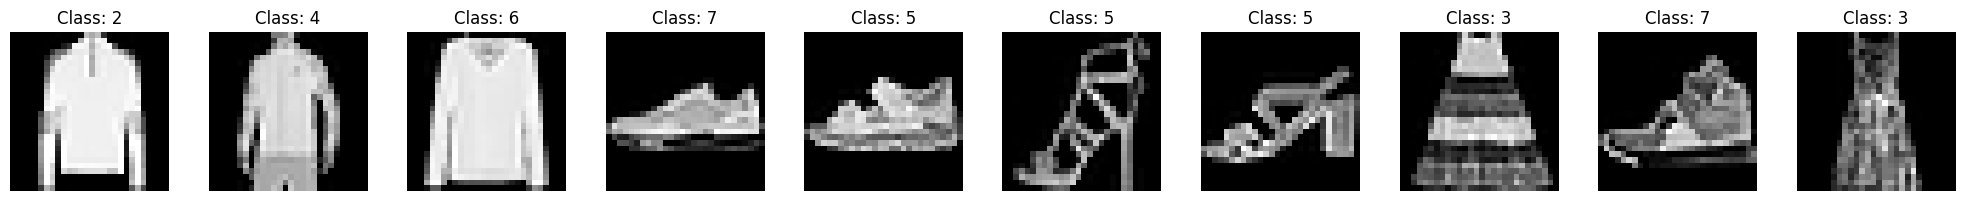

In [ ]:
# 원본 훈련 이미지를 1x10 그리드로 출력
fig, axs = plt.subplots(1, 10, figsize=(20, 2))

for i in range(10):
    ax = axs[i]
    ax.imshow(X_train[i].reshape(28, 28), cmap='gray')      # Fashion MNIST는 그레이스케일 이미지
    ax.set_title(f"Class: {Y_train[i]}")                    # 클래스 레이블 표시
    ax.axis('off')

plt.tight_layout()
plt.show()


### 3.2 데이터 증강

모델 훈련 중에 사용될 데이터 증강 파이프라인을 설정해보겠습니다.   
TorchVision 라이브러리의 transform 모듈 [참조 링크](https://pytorch.org/vision/main/auto_examples/transforms/plot_transforms_getting_started.html#getting-started-with-transforms-v2)

모델이 다양한 노이즈 환경에서 안정적으로 작동할 수 있게 돕고, 다양한 변형 데이터에 대한 일반화를 유도하기 위해 이미지에 잡음을 추가합니다. 여기서는 앞에서 미리 함수로 정의한 `Salt-and-pepper`<sub>5</sub> 와 `Gaussian Noise`<sub>6</sub> 두 가지 방법을 사용합니다.    

---
</dir> 참조 </br>
</dir> [5] salt-and-pepper: 무작위로 흰색(salt)와 검은색(pepper)를 추가해 노이즈를 생성하는 방법</br>
</dir> [6] gaussian noise: 이미지의 픽셀 값에 가우시안 분포에 따른 랜덤한 변동을 주어 노이즈를 생성하는 방법</br>
</dir> [Colab Notebook: Adding Noise to Image data for Deep learning Data Augmentation](https://buly.kr/1GJFuep) </br>

In [ ]:
# PyTorch의 torchvision.transforms 모듈에서 제공하는 기능을 활용해 데이터를 증강합니다.
augmentation_transforms = transforms.Compose([
    # 기하학적 변환
    transforms.RandomAffine(
        degrees=(-20, 20),          # 최대 -20도에서 20도 회전 범위
        translate=(0.2, 0.2),       # 최대 20% 이동
        scale=(0.8, 1.2),           # 최대 20% 크기 조정 범위
        shear=(-20, 20),            # 최대 20% 전단(비틀림)
        fill=0.0                    # 변형으로 인해 생기는 빈 공간은 흰색으로 채우기
    ),
    transforms.RandomHorizontalFlip(p=0.25),
    transforms.RandomVerticalFlip(p=0.25),

    # Noise and perturbations
    transforms.RandomApply([
        transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0))
    ], p=0.5),
    transforms.RandomChoice([
        GaussianNoise(mean=0.0, std=0.05),
        SaltAndPepperNoise(prob=0.05)
    ]),

    # Intensity adjustments
    transforms.ColorJitter(brightness=0.5, contrast=0.5),
])

모델을 훈련하기 전에, 증강된 이미지들이 어떻게 보이는지 살펴보겠습니다.  
약간의 노이즈가 추가된, 소금&후추가 뿌려지고- 뒤집어지고- 크기가 제각각인- 이미지 모음이 생성되는 것을 볼 수 있습니다.  
이렇게 많은 증강 이미지들이 훈련에 사용되면 모델은 원본을 거의 기억하지 못할 것입니다.

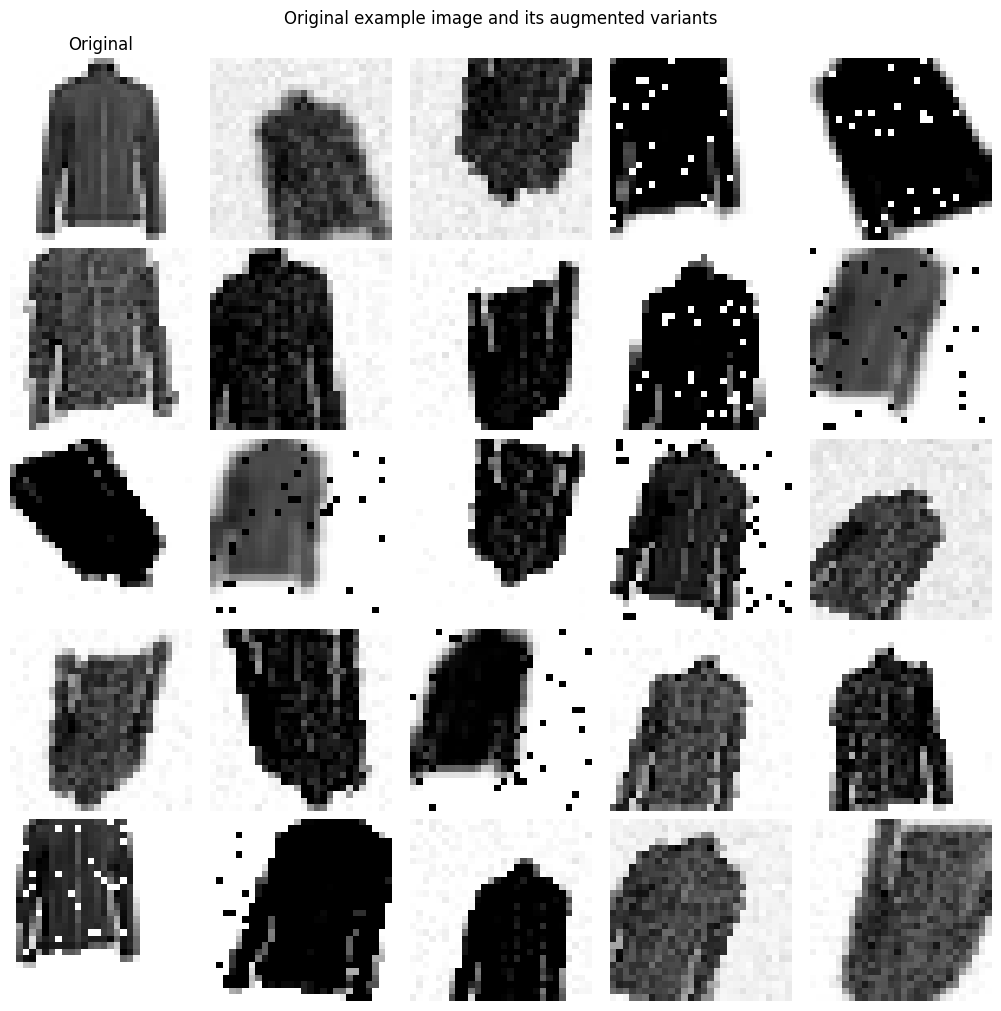

In [ ]:
# 이 코드는 실행할 때마다 다른 원본 이미지(+추가변형)를 랜덤하게 꺼내 보여줍니다.
# X_train 데이터셋에서 임의의 이미지를 선택하고, 다양한 증강 기법을 적용한 후
# 원본과 변형본을 시각적으로 비교할 수 있도록 출력합니다.
image = X_train[np.random.randint(len(X_train))]
augs = apply_augmentation(image, augmentation_transforms, num_samples=24) # 하나의 원본 이미지에 대한 24개의 변형된 버전이 저장됩니다.

fig, axes = plt.subplots(5, 5, figsize=(10, 10))
fig.suptitle('Original example image and its augmented variants')

for i, ax in enumerate(axes.ravel()):
    ax.axis('off')
    ax.imshow(image.reshape(int(image.shape[0]**0.5), -1) if i == 0 else augs[i-1], cmap='Greys')
    ax.set_title('Original' if i == 0 else '')

### 3.3 분류기 훈련(fitting)하기

이제 본격적으로 모델을 정의하고 훈련에 들어가보겠습니다.  
주의 사항이 하나 있습니다! 이 과정은 시간이 꽤 걸립니다. 커피를 가져오거나, 책상을 정리하거나, 고양이를 쓰다듬거나, 아무튼 진행 표시줄이 천천히 움직이는 것을 바라보는 것보다는 좀 더 보람된 일을 찾는 것을 추천합니다. 훈련은 100 에포크 후에 종료되거나, 조기 종료가 발동하면 더 일찍 멈춥니다. 여기서는 검증 데이터셋 증강을 사용하고 있기 때문에(검증 풀에서 이미지를 가져올 때마다 새로운 변형이 생성됩니다. 에포크가 길어져도 왠만해서는 과적합되기 힘든 상황을 유도하는 것입니다.), 조기종료가 발생했다면 -과적합에 의한 우연이 아니라- 모델이 충분히 학습했다는 뜻입니다. 즉, 끊임없이 변화하는 훈련 데이터에서 더 이상 추가 정보를 얻을 수 없다는 뜻입니다.   

필수는 아니지만, 빠르고 안정적인 학습을 위해서 훈련 데이터를 정규화합니다. `ravel()` 함수가 다차원 이미지 배열을 1차원 벡터로 변환해준 뒤에, 전체 평균과 표준편차를 구합니다. 입력 데이터의 값이 일정한 범위 내에 있어야 모델이 더 잘 학습할 수 있습니다. 그리고 로컬에서 학습할 거라면 CUDA 백엔드를 활용하세요. CUDA없이 실행한다면, 아마 내일 결과를 확인하게 될 지도 몰라요.

실전에서는 굉장히 오랜 시간 모델을 학습시켰지만, 여기서는 견본으로 100 에포크만 실행하겠습니다.

In [ ]:
# 모델 정의
model = EfficientNetClassifier(num_classes=len(np.unique(Y_train)),
                               augmentation = augmentation_transforms,
                               metrics = ['accuracy'],
                               device='cuda' if torch.cuda.is_available() else 'cpu', # cuda 우선 사용
                               mean=X_train.ravel().mean(),                           # 안정적인 학습을 위한 정규화
                               std=X_train.ravel().std())

In [ ]:
# 콜백 인스턴스 생성
save_callback = SaveModelEveryNEpochs(save_path='model_checkpoints', every_n_epochs=50)

# 모델 학습
model.fit(X_train,
          Y_train,
          X_val,
          Y_val,
          augment_val = True,
          n_epochs = 100,
          patience = 30,           # -1 은 조기 종료 해제
          batch_size = 64,
          verbose = 1,
          callbacks=[save_callback])

Fitting...:  10%|█         | 10/100 [02:19<20:49, 13.89s/it, train_loss=1.6262, val_loss=1.5058, train_accuracy=0.4588, val_accuracy=0.5099]


Model saved at epoch 10 to model_checkpoints/model_epoch_10.pt


Fitting...:  20%|██        | 20/100 [04:38<18:32, 13.91s/it, train_loss=1.3018, val_loss=1.2165, train_accuracy=0.6336, val_accuracy=0.6682]


Model saved at epoch 20 to model_checkpoints/model_epoch_20.pt


Fitting...:  30%|███       | 30/100 [06:57<16:09, 13.85s/it, train_loss=1.1814, val_loss=1.1797, train_accuracy=0.6911, val_accuracy=0.6712]

...


Model saved at epoch 80 to model_checkpoints/model_epoch_80.pt


Fitting...:  90%|█████████ | 90/100 [20:55<02:19, 13.97s/it, train_loss=0.9349, val_loss=1.0425, train_accuracy=0.7993, val_accuracy=0.7747]


Model saved at epoch 90 to model_checkpoints/model_epoch_90.pt


Fitting...: 100%|██████████| 100/100 [23:14<00:00, 13.95s/it, train_loss=0.9286, val_loss=1.0006, train_accuracy=0.8054, val_accuracy=0.7747]


Model saved at epoch 100 to model_checkpoints/model_epoch_100.pt


### 3.4 Evaluation

다음으로, 모델이 훈련 데이터셋과 검증 데이터셋에 대해 어떻게 수행했는지, 에포크별 정확도를 통해 살펴보겠습니다. 시각화를 통해서 TTA를 사용했을 때와 하지 않았을 때의 수치를 비교해보겠습니다. (훈련 결과와 그에 대한 분석은 실행할때마다 다를 수 있습니다.)

최종 정확도 수치는 아래에도 표시되어 있습니다. 테스트 세트에 대해서도 모델이 안정적으로 유지되고 있음을 알 수 있습니다. 한 가지 더 주목할 점은, 이번에는 TTA가 정확도에 특별한 향상을 가져오지 않았다는 것입니다. 오히려 살짝 더 낮은 성능을 보여주는군요.

Predicting: 100%|██████████| 62/62 [00:03<00:00, 17.78it/s, batch=62/62, samples=1968]


Training accuracy (TTA=0): 0.9004065040650406


Predicting: 100%|██████████| 21/21 [00:01<00:00, 19.90it/s, batch=21/21, samples=657]


Validation accuracy (TTA=0): 0.8417047184170472


Predicting: 100%|██████████| 28/28 [00:01<00:00, 18.74it/s, batch=28/28, samples=875]


...

Training accuracy (TTA=50): 0.891260162601626


Predicting with TTA: 100%|██████████| 1050/1050 [01:29<00:00, 11.80it/s, batch=21/21, samples=32850, tta=50/50]


Validation accuracy (TTA=50): 0.8356164383561644


Predicting with TTA: 100%|██████████| 1400/1400 [01:57<00:00, 11.94it/s, batch=28/28, samples=43750, tta=50/50]


Test accuracy (TTA=50): 0.8365714285714285


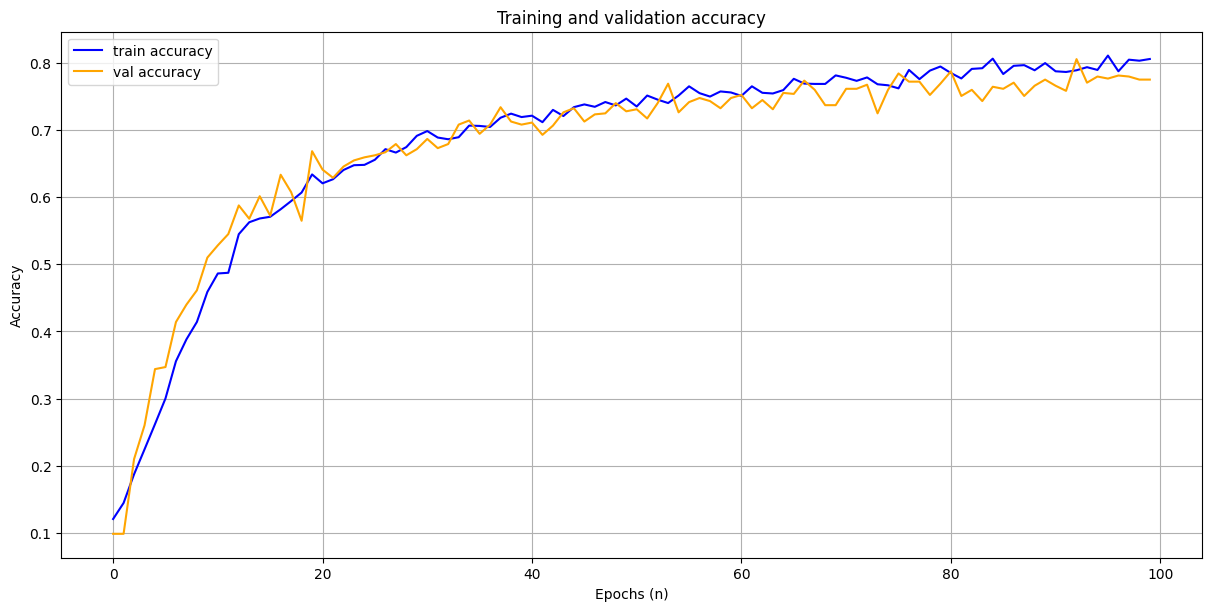

In [ ]:
# 훈련 / 검증 지표 추출
train_metrics, val_metrics = model.train_metrics, model.val_metrics

# 훈련 / 검증 정확도 시각화
fig, ax = plt.subplots()
ax.set(title='Training and validation accuracy', xlabel='Epochs (n)', ylabel='Accuracy')
ax.grid()
ax.plot(train_metrics['accuracy'], c='blue', label='train accuracy')
ax.plot(val_metrics['accuracy'], c='orange', label='val accuracy')
ax.legend()

tta = 0     # 데이터 증강을 하지 않습니다.
print(f'Training accuracy (TTA={tta}): {accuracy_score(Y_train, model.predict(X_train, tta = tta, verbose = 1))}')  # accracy_score()함수가 model.predict()를 실행합니다.
print(f'Validation accuracy (TTA={tta}): {accuracy_score(Y_val, model.predict(X_val, tta = tta, verbose = 1))}')
print(f'Test accuracy (TTA={tta}): {accuracy_score(Y_test, model.predict(X_test, tta = tta, verbose = 1))}')

tta = 50    # 하나의 원본 이미지당 50장을 증강합니다.
print(f'Training accuracy (TTA={tta}): {accuracy_score(Y_train, model.predict(X_train, tta = tta, verbose = 1))}')
print(f'Validation accuracy (TTA={tta}): {accuracy_score(Y_val, model.predict(X_val, tta = tta, verbose = 1))}')
print(f'Test accuracy (TTA={tta}): {accuracy_score(Y_test, model.predict(X_test, tta = tta, verbose = 1))}')

In [ ]:
# 모델 로드
#model_path = './sample_data/model_checkpoints/model_epoch_100.pt'
#model.model.load_state_dict(torch.load(model_path))

이제 모델이 잘못 예측한 샘플을 한 번 보겠습니다.  
틀린 예측은 모델의 성능을 향상시키기 위한 중요한 단서를 제공할 수 있습니다.  
어떤 유형의 이미지에서 모델이 실수하는지, 특정 클래스가 다른 클래스와 자주 혼동되는지 확인해봅시다.  
  
Fashion-MNIST는 의류 제품의 이미지를 포함하고 있으며, T-shirt, Shirt, Pullover, Coat 등과 같은 클래스 간의 유사성 때문에 충분히 잘못된 예측이 발생할 수 있습니다. 사람이라도 올바른 레이블을 항상 식별하기는 어려울 수 있으니까 모델에게 관대해집시다.  

Predicting: 100%|██████████| 21/21 [00:01<00:00, 16.72it/s, batch=21/21, samples=657]


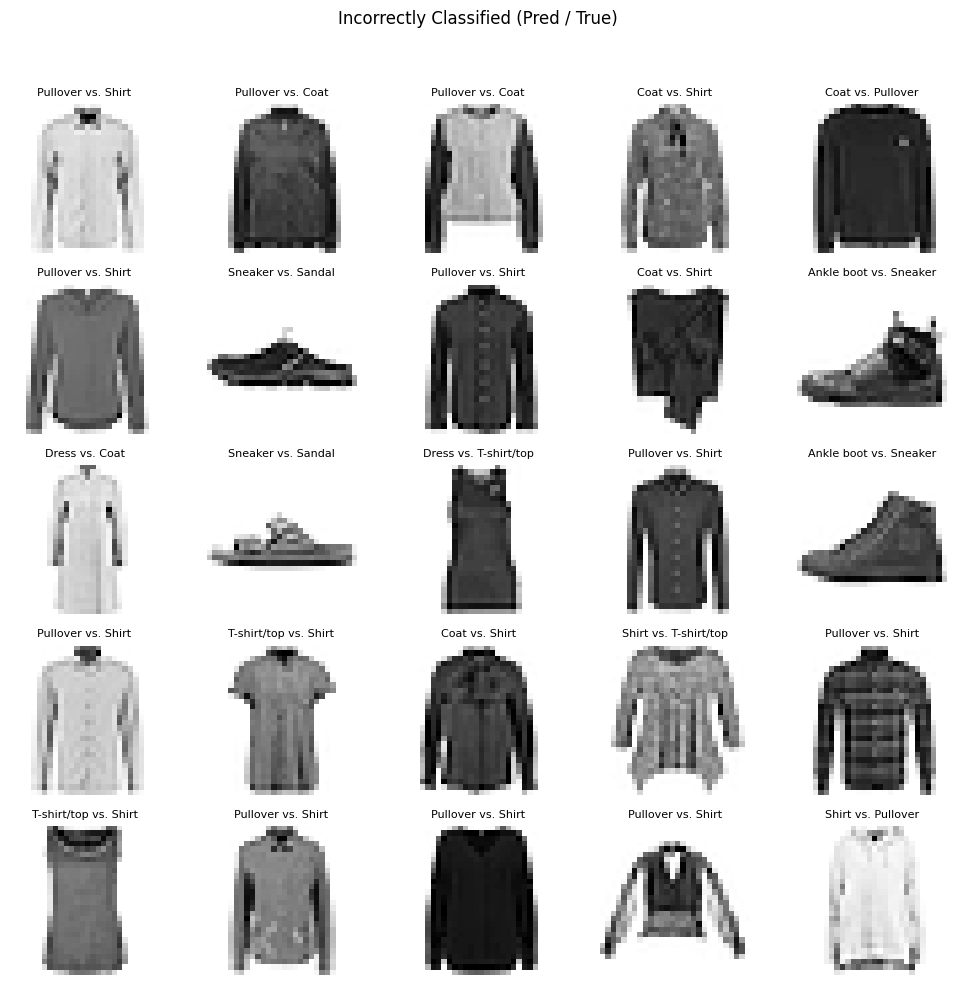

In [ ]:
# 틀린 예측을 한 샘플 찾기
Y_val_pred = model.predict(X_val, tta=0)            # Test-Time Augmentation을 사용하지 않고 모델 예측
incorrect_idx = Y_val_pred != Y_val                 # 모델의 예측값(Y_val_pred)과 실제 정답(Y_val)을 비교해 잘못 예측한 샘플의 인덱스 저장
X_incorrect = X_val[incorrect_idx]                  # 잘못 예측한 샘플의 인덱스로 샘플(이미지) 추출
Y_pred_incorrect = Y_val_pred[incorrect_idx]        # 잘못 예측한 샘플들에 대한 모델의 예측값
Y_true_incorrect = Y_val[incorrect_idx]             # 잘못 예측한 샘플들의 실제 정답

# 원래 이미지 차원 계산
dim = int(np.sqrt(X_val.shape[1]))

# 5x5 그리드 시각화
fig, ax = plt.subplots(5, 5, figsize=(10, 10))
fig.suptitle('Incorrectly Classified (Pred / True)')                            # 왼쪽: 예측 라벨 | 오른쪽: 정답 라벨
ax = ax.ravel()

# 잘못 예측한 샘플 중 랜덤하게 시각 (최대 25)
n_samples = min(25, len(X_incorrect))
if n_samples:
    idxs = np.random.choice(len(X_incorrect), n_samples, replace=False)         # replace=False 는 중복 제거
    for i, idx in enumerate(idxs):
        ax[i].imshow(X_incorrect[idx].reshape(dim, dim), cmap='Greys')
        ax[i].set_title(f'{classes[Y_pred_incorrect[idx]]} vs. {classes[Y_true_incorrect[idx]]}', fontsize=8)
        ax[i].axis('off')
    for i in range(n_samples, 25):
        ax[i].axis('off')
    plt.tight_layout(rect=[0, 0, 1, 0.95])                                      # 서브플롯 간의 간격 자동 조정
    plt.show()

### 3.6 테스트 시간 증강(Test-Time Augmentation)의 영향 평가

테스트 시간 증강(TTA)이 정확도를 얼마나 향상시킬 수 있는지 확인하기 위해 다양한 수준의 증강을 적용하여 간단한 실험을 진행해 보겠습니다. 아래 그래프에서 볼 수 있듯이, TTA는 여기서 큰 효과를 보이지 않는 것 같습니다. 아마도 모델이 이러한 변형된 버전들에 대해 이미 꽤 확신을 가지고 있거나, 또는 적용한 증강 기법들(소금&후추,가우시안)이 처음부터 너무 어려웠을 수 있습니다. 이를 확인하려면 예측 결과를 좀 더 자세히 살펴봐야 하겠지만, 지금은 이 정도로 마무리하겠습니다.

Predicting...: 100%|██████████| 10/10 [15:27<00:00, 92.73s/it, TTA=90, accuracy=[90.     0.831]] 


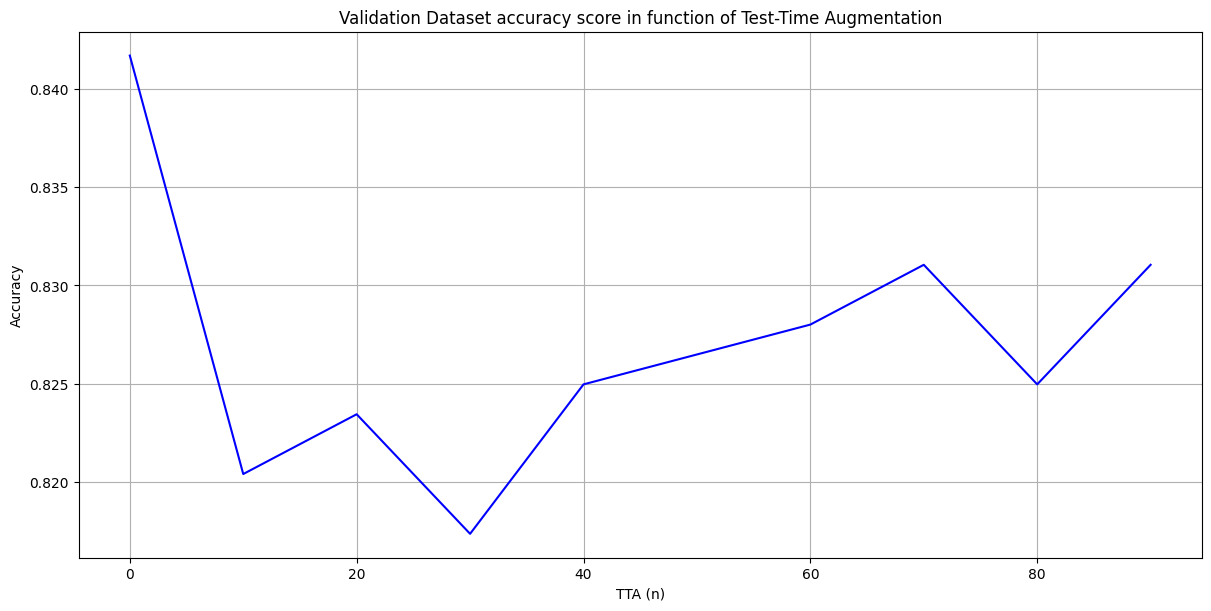

In [ ]:
tta_pbar = tqdm(np.arange(0, 100, 10), desc = 'Predicting...')
tta_accuracy_scores = []
for tta in tta_pbar:
    tta_accuracy_scores.append((tta, accuracy_score(Y_val, model.predict(X_val, tta = tta, verbose = 0))))
    tta_pbar.set_postfix({'TTA': tta, 'accuracy': np.round(tta_accuracy_scores[-1], 3)})
tta_accuracy_scores = np.array(tta_accuracy_scores)

fig, ax = plt.subplots()
ax.set_title('Validation Dataset accuracy score in function of Test-Time Augmentation')     # TTA를 적용했을 때 검증 정확도 그래프
ax.set_xlabel('TTA (n)')
ax.set_ylabel('Accuracy')
ax.grid()
ax.plot(tta_accuracy_scores[:, 0], tta_accuracy_scores[:, 1], c = 'blue')

## 4. 결론

이 노트북에서는 PyTorch를 활용한 그레이스케일 이미지 분류 작업을 위한 견고한 베이스 모델을 제공하고자 했습니다. 복잡한 설정 없이도 바로 시작할 수 있는 기반을 마련하는 것이 목표였습니다. 여기서 제공된 클래스들은 PyTorch의 이미지 분류 도구를 활용하는 데 분명한 길잡이가 되어줄 것입니다. 검증 설정, 조기 종료, 모델 훈련 및 예측과 같은 기본적인 작업들을 일일이 구현할 필요 없이 바로 사용할 수 있습니다.

앞서 언급했듯이, 이 모델은 의도적으로 단순함을 유지하면서도 필수적인 기능들을 갖추고 있습니다. 자유롭게 조정 가능한 이미지 증강 기법, 작은 데이터셋을 가지고 있을 때- 훈련 과정에서 더 정확한 평가를 도와줄 수 있는 검증 시간 증강, 그리고 중요한 상황에서 성능 향상에 도움을 줄 수 있는 테스트 시간 증강(TTA)을 포함합니다. 특히 복잡하고 까다로운 문제에 직면했을 때 이러한 기능들이 큰 도움이 될 것입니다.